
# Pré-processamento de Dados com pandas e scikit-learn (com Pipelines)

Este notebook cobre, de forma prática, as principais etapas de **pré-processamento de dados** para projetos de Ciência de Dados e Machine Learning, com exemplos em **pandas** e **scikit-learn**:

- Valores nulos (detecção e imputação)
- Codificação de variáveis categóricas (Label Encoding e One-Hot)
- Padronização e normalização de escalas
- Divisão treino/teste (e validação)
- Pipelines e `ColumnTransformer` (fluxo end-to-end)
- Tratamento de outliers (IQR capping)
- Dicas extras para datas e textos

> Observação: todos os exemplos usam dados sintéticos/pequenos apenas para fins didáticos.



## Por que o pré-processamento é crítico?

O pré-processamento é a etapa mais crítica e, frequentemente, a mais demorada em um projeto de ciência de dados e ML. A frase **"garbage in, garbage out"** resume a importância: **a qualidade do modelo depende diretamente da qualidade dos dados**.

**Desafios comuns que o pré-processamento resolve:**  
1. **Dados faltantes:** muitos modelos não lidam com `NaN`/`None`.  
2. **Ruído e outliers:** valores extremos (ex.: idade 999) distorcem estatísticas.  
3. **Inconsistências:** mesma entidade escrita de formas diferentes; formatos mistos (datas).  
4. **Tipos inadequados:** número salvo como texto, categorias como número, etc.  
5. **Variáveis categóricas:** a maioria dos modelos trabalha só com números.  
6. **Escalas diferentes:** recursos com magnitudes distintas desequilibram alguns algoritmos.

A seguir, veremos soluções práticas com **pandas** e **scikit-learn**, padronizando tudo via **Pipelines**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score




## 1) Valores Nulos (Missing Values)

### Detecção


In [5]:
df_nulos = pd.DataFrame({'col1': [1, 2, np.nan], 'col2': [4, np.nan, 6]})

display(df_nulos)

,col1,col2
0,1.0,4.0
1,2.0,NaN
2,NaN,6.0


In [6]:
print("Valores nulos por coluna:")
print(df_nulos.isnull().sum())
df_nulos


Valores nulos por coluna:
col1    1
col2    1
dtype: int64


,col1,col2
0,1.0,4.0
1,2.0,NaN
2,NaN,6.0



### Estratégias de Tratamento

- **Remoção**: `dropna()` (use com cautela).
- **Imputação** (preenchimento): média, mediana, moda ou valor constante.

A seguir, exemplos com **pandas** e com o **SimpleImputer** (preferível para uso em **Pipelines**).


In [7]:
# Usando pandas: preencher 'col1' com a média
df_fill = df_nulos.copy()

media_col1 = df_fill['col1'].mean()

df_fill['col1'] = df_fill['col1'].fillna(media_col1)

print("DataFrame após preencher 'col1' com a média (pandas):")
print(df_fill)

media_col2 = df_nulos['col2'].mean()

df_fill['col2'] = df_fill['col2'].fillna(media_col2)

print("DataFrame após preencher 'col2' com a média (pandas):")
print(df_fill)

DataFrame após preencher 'col1' com a média (pandas):
   col1  col2
0   1.0   4.0
1   2.0   NaN
2   1.5   6.0
DataFrame após preencher 'col2' com a média (pandas):
   col1  col2
0   1.0   4.0
1   2.0   5.0
2   1.5   6.0


In [8]:
# Remover linhas com qualquer valor nulo
df_linhas_removidas = df_nulos.dropna()
print("\nDataFrame após remover linhas com valores nulos:")
print(df_linhas_removidas)




DataFrame após remover linhas com valores nulos:
   col1  col2
0   1.0   4.0


In [9]:
# Remover colunas com qualquer valor nulo
df_colunas_removidas = df_nulos.dropna(axis=1)
print("\nDataFrame após remover colunas com valores nulos:")
print(df_colunas_removidas)


DataFrame após remover colunas com valores nulos:
Empty DataFrame
Columns: []
Index: [0, 1, 2]


In [10]:
# Usando SimpleImputer (para integrar em Pipelines)
num_imputer = SimpleImputer(strategy='median')

filled = num_imputer.fit_transform(df_nulos)

df_imputed = pd.DataFrame(filled, columns=df_nulos.columns)
print("\nDataFrame imputado com SimpleImputer (mediana):")
print(df_imputed)



DataFrame imputado com SimpleImputer (mediana):
   col1  col2
0   1.0   4.0
1   2.0   5.0
2   1.5   6.0



## 2) Codificação de Variáveis Categóricas

### Label Encoding (ordinal)
Use quando houver **ordem natural** entre as categorias (ex.: P < M < G).


In [12]:
df_cat = pd.DataFrame({'produtos': ['camiseta', 'calça', 'jaqueta', 'bermuda', 'camiseta'],
                       'tamanho': ['P', 'G', 'M', 'G', 'P']})
display(df_cat)

,produtos,tamanho
0,camiseta,P
1,calça,G
2,jaqueta,M
3,bermuda,G
4,camiseta,P


In [13]:

le = LabelEncoder()
df_cat['tamanho_encoded'] = le.fit_transform(df_cat['tamanho'])
df_cat


,produtos,tamanho,tamanho_encoded
0,camiseta,P,2
1,calça,G,0
2,jaqueta,M,1
3,bermuda,G,0
4,camiseta,P,2



### One-Hot Encoding (nominal)
Use para categorias **sem ordem**. No `scikit-learn`, prefira `OneHotEncoder` (especialmente em `ColumnTransformer`), pois ele se integra ao pipeline e lida com categorias desconhecidas em produção.


In [14]:

df_ohe = pd.DataFrame({'produtos': ['camiseta', 'calça', 'jaqueta', 'bermuda', 'categoria'],
                       'cor': ['vermelho', 'azul', 'verde', 'amarelo', 'azul']})
# pandas.get_dummies() (rápido e simples)

display(df_ohe)

,produtos,cor
0,camiseta,vermelho
1,calça,azul
2,jaqueta,verde
3,bermuda,amarelo
4,categoria,azul


#### get_dummies() é uma função do pandas que converte variáveis categóricas em variáveis indicadoras ou "dummy" (binárias). Essencialmente, é uma maneira simples e eficiente de realizar o One-Hot Encoding.

### Como funciona?
##### Para cada valor único em uma coluna categórica, get_dummies() cria uma nova coluna. Se o valor da linha original pertencer àquela categoria, a nova coluna recebe o valor 1; caso contrário, recebe 0.

In [15]:
df_ohe_pd = pd.get_dummies(df_ohe, columns=['cor'], prefix='cor')
print("Com pandas.get_dummies():")
display(df_ohe_pd)

Com pandas.get_dummies():


,produtos,cor_amarelo,cor_azul,cor_verde,cor_vermelho
0,camiseta,False,False,False,True
1,calça,False,True,False,False
2,jaqueta,False,False,True,False
3,bermuda,True,False,False,False
4,categoria,False,True,False,False


In [16]:
# OneHotEncoder do scikit-learn (para pipelines)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df_ohe[['cor']])

df_ohe_skl = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['cor']))

print("\nCom OneHotEncoder (sklearn):")
display(df_ohe_skl)


Com OneHotEncoder (sklearn):


,cor_amarelo,cor_azul,cor_verde,cor_vermelho
0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0



## 3) Padronização e Normalização

- **Padronização** (`StandardScaler`): transforma dados para média 0 e desvio 1  
  Fórmula: \( z = \frac{x - \mu}{\sigma} \)

- **Normalização** (`MinMaxScaler`): reescala para um intervalo fixo (ex.: 0 a 1)  
  Fórmula: \( x' = \frac{x - \min(x)}{\max(x) - \min(x)} \)


In [19]:
data_scale = np.array([[10, 100], [20, 200], [30, 300]])

display(data_scale)

array([[ 10, 100],
       [ 20, 200],
       [ 30, 300]])

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_scale)
print("Dados padronizados (média ~0, desvio ~1):")
display(np.round(scaled_data, 3))

Dados padronizados (média ~0, desvio ~1):


array([[-1.225, -1.225],
       [ 0.   ,  0.   ],
       [ 1.225,  1.225]])

fit (Ajustar): A "ferramenta" (scaler) analisa os dados de entrada (data_scale) para calcular a média (
mu) e o desvio padrão (
sigma) de cada feature. Esses valores são armazenados internamente.

Para a primeira coluna ([10, 20, 30]), a média é 20 e o desvio padrão é 8.16.

Para a segunda coluna ([100, 200, 300]), a média é 200 e o desvio padrão é 81.65.

transform (Transformar): Em seguida, a ferramenta usa os valores de média e desvio padrão que ela acabou de aprender para transformar os dados. Ela aplica a fórmula de padronização (z=
fracx−musigma) a cada valor individual, gerando a nova matriz scaled_data.



In [22]:
minmax = MinMaxScaler()
normalized_data = minmax.fit_transform(data_scale)
print("\nDados normalizados (0-1):")
print(np.round(normalized_data, 3))



Dados normalizados (0-1):
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


fit (Ajuste): O MinMaxScaler examina seus dados de entrada (data_scale) para encontrar o valor mínimo e máximo de cada coluna (feature).

Para a primeira coluna, o mínimo é 10 e o máximo é 30.

Para a segunda coluna, o mínimo é 100 e o máximo é 300.

transform (Transformação): O scaler usa esses valores de mínimo e máximo para aplicar a fórmula de normalização em cada dado, convertendo-o para o novo intervalo. A fórmula é:

x' = max(x)−min(x)/x−min(x)
​ 
O resultado é armazenado na variável normalized_data.



### Visualização simples (antes/depois)


In [23]:
# Distribuição de uma coluna antes e depois do StandardScaler
x = np.array([10, 20, 30, 50, 80, 130, 210, 340]).reshape(-1, 1)

display(x)

array([[ 10],
       [ 20],
       [ 30],
       [ 50],
       [ 80],
       [130],
       [210],
       [340]])

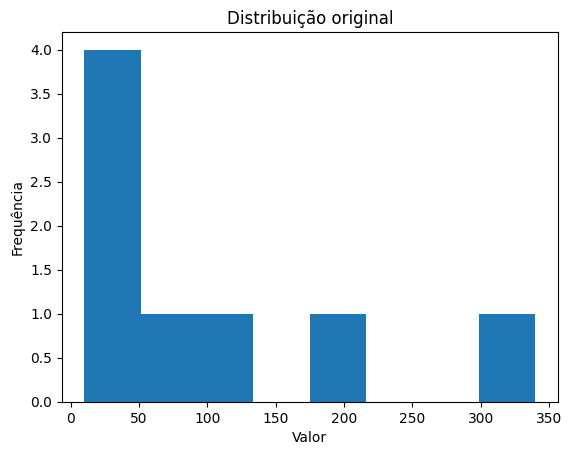

In [24]:
fig = plt.figure()
plt.hist(x.flatten(), bins=8)
plt.title("Distribuição original")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

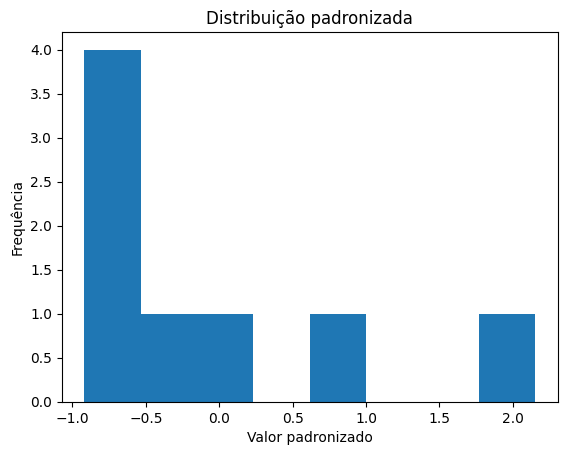

In [25]:
sc = StandardScaler()
x_std = sc.fit_transform(x)

fig = plt.figure()
plt.hist(x_std.flatten(), bins=8)
plt.title("Distribuição padronizada")
plt.xlabel("Valor padronizado")
plt.ylabel("Frequência")
plt.show()



## 4) Divisão dos Dados (Treino/Teste/Validação)

- **Treino**: o modelo aprende padrões.  
- **Validação**: ajuste de hiperparâmetros (pode ser via *cross-validation*).  
- **Teste**: estimativa final de generalização.

Abaixo, um exemplo simples com `train_test_split`.


In [ ]:
df_split = pd.DataFrame({'metragem do imóvel': range(100), 'idade do imóvel': range(100, 200), 'preço do imóvel': np.random.randint(0, 2, 100)})

display(df_split)

In [ ]:

# Separa X e y
X = df_split[['metragem do imóvel', 'idade do imóvel']]
y = df_split['preço do imóvel']

display(X)
display(y)

In [ ]:


# Divide 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto X_train: {X_train.shape}")
print(f"Tamanho do conjunto X_test: {X_test.shape}")
print("Proporção de classes no treino vs. teste:")
print(pd.Series(y_train).value_counts(normalize=True).rename("train"))
print(pd.Series(y_test).value_counts(normalize=True).rename("test"))



## 5) Pipelines e `ColumnTransformer` (fluxo end-to-end)

Aqui montamos um exemplo completo com:
- Colunas numéricas com **imputação** (mediana) + **padronização**
- Colunas categóricas com **imputação** (mais frequente) + **One-Hot**
- (Opcional) tratamento simples de datas com um `FunctionTransformer`

Em seguida, treinamos um **LogisticRegression** no pipeline e avaliamos.


In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


# Criando um dataset sintético com faltantes e categorias
rng = np.random.RandomState(7)
n = 200

df = pd.DataFrame({
    'idade': rng.randint(18, 80, n).astype(float),
    'renda': rng.normal(6000, 2000, n).astype(float),
    'cidade': rng.choice(['São Paulo', 'SP', 'Sao Paulo', 'Belo Horizonte', 'BH', 'Rio de Janeiro', 'RJ'], n),
    'data_cadastro': pd.to_datetime('2022-01-01') + pd.to_timedelta(rng.randint(0, 365, n), unit='D'),
    'alvo': rng.binomial(1, 0.45, n)
})

# Inserindo faltantes e inconsistências
df.loc[rng.choice(n, 15), 'idade'] = np.nan
df.loc[rng.choice(n, 10), 'renda'] = np.nan
df.loc[rng.choice(n, 8), 'cidade'] = None

display(df.head(50))

In [ ]:
# Padronizando algumas entradas da coluna 'cidade'
def normaliza_cidade(series: pd.Series) -> pd.Series:
    m = series.fillna("").str.lower().str.replace(r"\s+", " ", regex=True)
    m = m.replace({
        'sp': 'são paulo',
        'sao paulo': 'são paulo',
        'bh': 'belo horizonte',
        'rj': 'rio de janeiro'
    })
    return m

# Extraindo features de data (ano, mês, dia) via FunctionTransformer
def extrai_partes_data(df_sub: pd.DataFrame) -> pd.DataFrame:
    d = df_sub['data_cadastro']
    out = pd.DataFrame({
        'ano': d.dt.year,
        'mes': d.dt.month,
        'dia': d.dt.day
    }, index=df_sub.index)
    return out

# Colunas
num_features = ['idade', 'renda']
cat_features = ['cidade']
date_feature = ['data_cadastro']

# Transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Para a data, primeiro passamos a coluna e extraímos partes com FunctionTransformer
date_extractor = FunctionTransformer(extrai_partes_data, validate=False)

# ColumnTransformer para combinar tudo
preprocess = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('date', Pipeline([('extract', date_extractor)]), date_feature),
    ],
    remainder='drop'
)

# Pipeline completo com um modelo de classificação
clf = Pipeline(steps=[
    ('cidade_norm', FunctionTransformer(lambda df_in: df_in.assign(cidade=normaliza_cidade(df_in['cidade'])), validate=False)),
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

X = df[['idade', 'renda', 'cidade', 'data_cadastro']]
y = df['alvo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Acurácia de teste:", round(accuracy_score(y_test, pred), 3))
print("\nRelatório de classificação:")
print(classification_report(y_test, pred))



## 6) Tratamento de Outliers (IQR capping)

Uma abordagem robusta é usar o intervalo interquartil (IQR) para **limitar/capar** valores extremos.

> **IQR = Q3 − Q1**. Valores abaixo de **Q1 − 1.5·IQR** ou acima de **Q3 + 1.5·IQR** podem ser considerados outliers.

Exemplo abaixo implementa **capping** (limitando ao limite inferior/superior).

O Código Passo a Passo
def iqr_capping(...): Define a função que implementa a lógica de capping, com um factor padrão de 1.5.

x = pd.Series(...): Cria uma série de dados de demonstração. A maior parte dos dados segue uma distribuição normal, mas o código adiciona intencionalmente valores extremos (5, 120, 200) para simular outliers.

x_capped = iqr_capping(x): Aplica a função iqr_capping para criar uma nova série de dados com os outliers limitados.

print(...): Mostra os valores mínimo e máximo dos dados antes e depois do capping, demonstrando o efeito da técnica. O valor máximo antes do capping é 200, e após o capping ele é limitado a um valor menor, provando que a função funcionou.

plt.hist(...): Gera histogramas para visualizar a distribuição dos dados antes e depois do capping. O histograma "Depois do IQR capping" mostra que os valores extremos foram "cortados" e agrupados em uma das barras nas extremidades, resultando em uma distribuição mais compacta e menos espalhada.

In [ ]:

def iqr_capping(series: pd.Series, factor: float = 1.5) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower, upper)

# Demonstração
rng = np.random.RandomState(0)
x = pd.Series(np.concatenate([rng.normal(50, 5, 100), [5, 120, 200]]))
x_capped = iqr_capping(x)

print("Antes: min=%.2f, max=%.2f" % (x.min(), x.max()))
print("Depois do capping: min=%.2f, max=%.2f" % (x_capped.min(), x_capped.max()))

fig = plt.figure()
plt.hist(x, bins=20)
plt.title("Antes do IQR capping")
plt.show()

fig = plt.figure()
plt.hist(x_capped, bins=20)
plt.title("Depois do IQR capping")
plt.show()
